In [1]:
# VigilPay | Day 3 — Exploratory Data Analysis (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/creditcard.csv")

print("✅ Libraries imported & dataset loaded!")
print(f"📐 Shape: {df.shape}")

✅ Libraries imported & dataset loaded!
📐 Shape: (284807, 31)


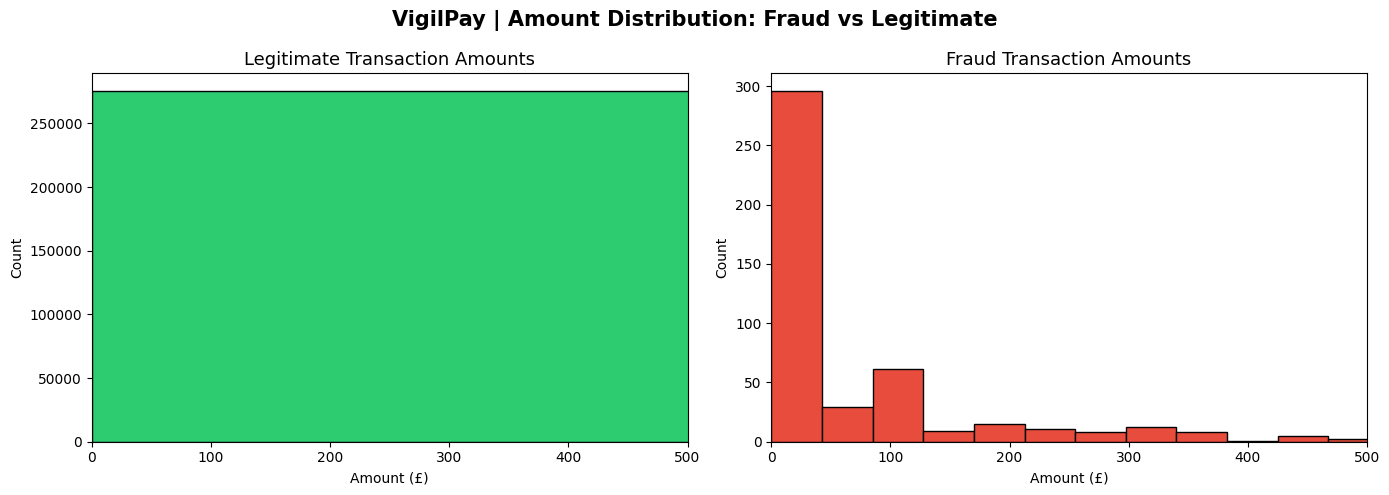

💰 Legitimate - Average Amount: £ 88.29
🚨 Fraud      - Average Amount: £ 122.21
💰 Legitimate - Max Amount:     £ 25691.16
🚨 Fraud      - Max Amount:     £ 2125.87


In [2]:
# How much money is involved in fraud vs legitimate transactions?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Legitimate transactions
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='#2ecc71', edgecolor='black')
axes[0].set_title('Legitimate Transaction Amounts', fontsize=13)
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 500)

# Fraud transactions
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='#e74c3c', edgecolor='black')
axes[1].set_title('Fraud Transaction Amounts', fontsize=13)
axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 500)

plt.suptitle('VigilPay | Amount Distribution: Fraud vs Legitimate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/amount_distribution.png')
plt.show()

# Print statistics
print("💰 Legitimate - Average Amount: £", round(df[df['Class']==0]['Amount'].mean(), 2))
print("🚨 Fraud      - Average Amount: £", round(df[df['Class']==1]['Amount'].mean(), 2))
print("💰 Legitimate - Max Amount:     £", round(df[df['Class']==0]['Amount'].max(), 2))
print("🚨 Fraud      - Max Amount:     £", round(df[df['Class']==1]['Amount'].max(), 2))

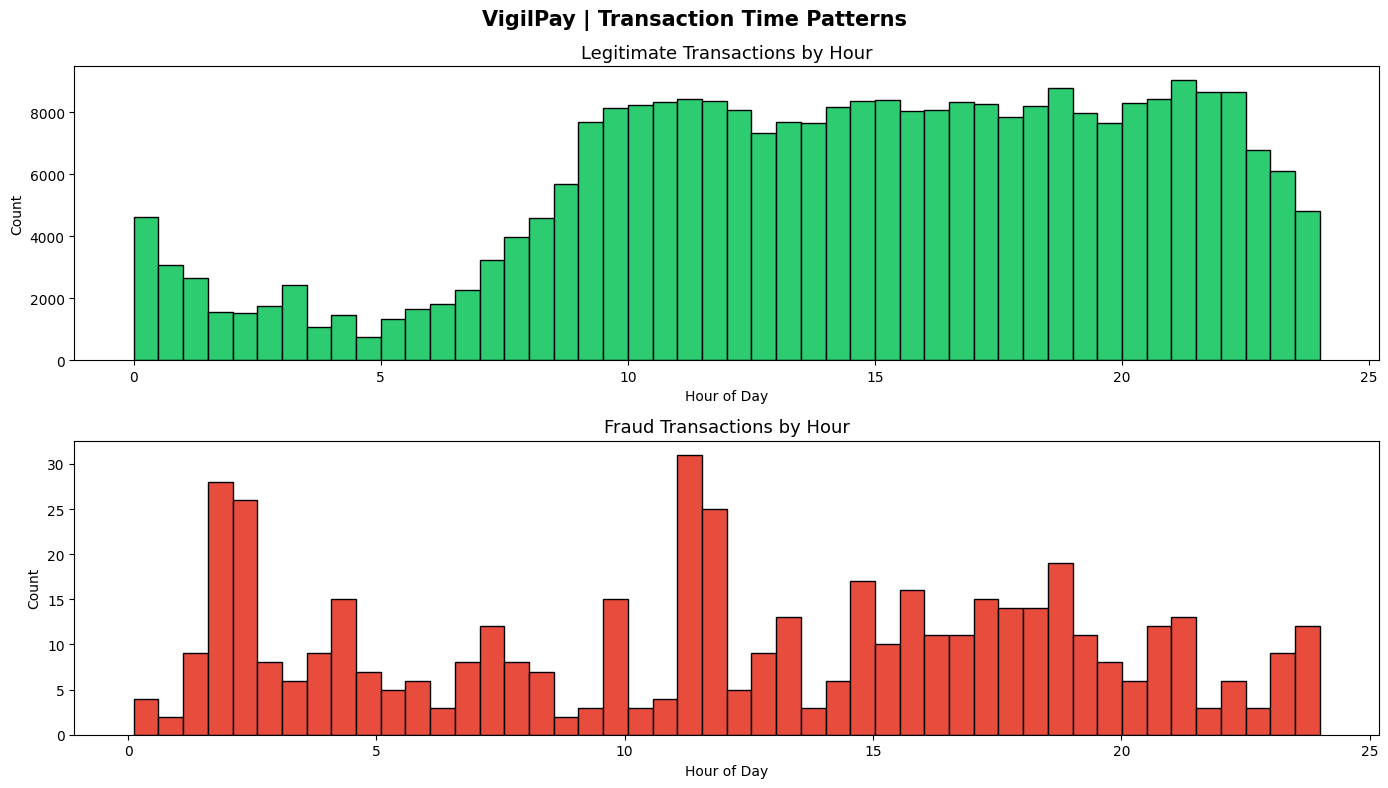

✅ Time chart saved!


In [3]:
# Convert Time from seconds to hours
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Legitimate
axes[0].hist(df[df['Class']==0]['Hour'], bins=48, color='#2ecc71', edgecolor='black')
axes[0].set_title('Legitimate Transactions by Hour', fontsize=13)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')

# Fraud
axes[1].hist(df[df['Class']==1]['Hour'], bins=48, color='#e74c3c', edgecolor='black')
axes[1].set_title('Fraud Transactions by Hour', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')

plt.suptitle('VigilPay | Transaction Time Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/time_distribution.png')
plt.show()
print("✅ Time chart saved!")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27176\669485207.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27176\669485207.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27176\669485207.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legit, fraud], labels=['Legitimate', 'Fraud'],


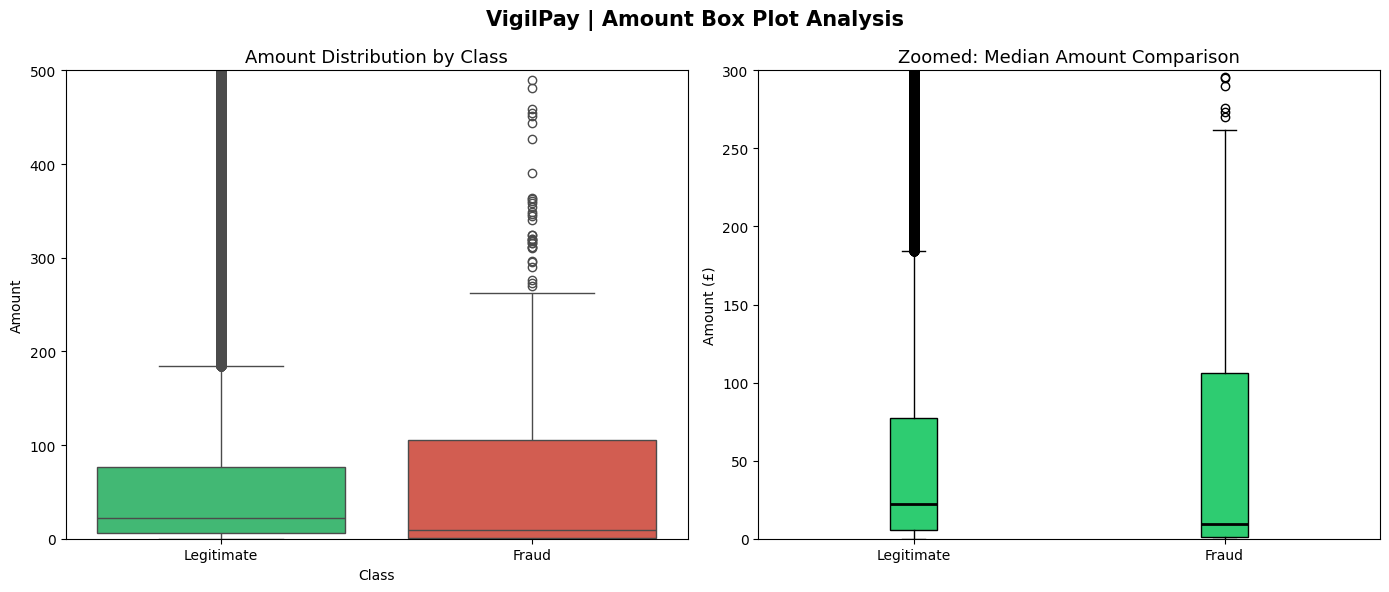

✅ Box plot saved!


In [4]:
# Side by side box plots for Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
sns.boxplot(x='Class', y='Amount', data=df, 
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Amount Distribution by Class', fontsize=13)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_ylim(0, 500)

# Zoom in version
fraud = df[df['Class']==1]['Amount']
legit = df[df['Class']==0]['Amount']

axes[1].boxplot([legit, fraud], labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Zoomed: Median Amount Comparison', fontsize=13)
axes[1].set_ylabel('Amount (£)')
axes[1].set_ylim(0, 300)

plt.suptitle('VigilPay | Amount Box Plot Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/boxplot_analysis.png')
plt.show()
print("✅ Box plot saved!")

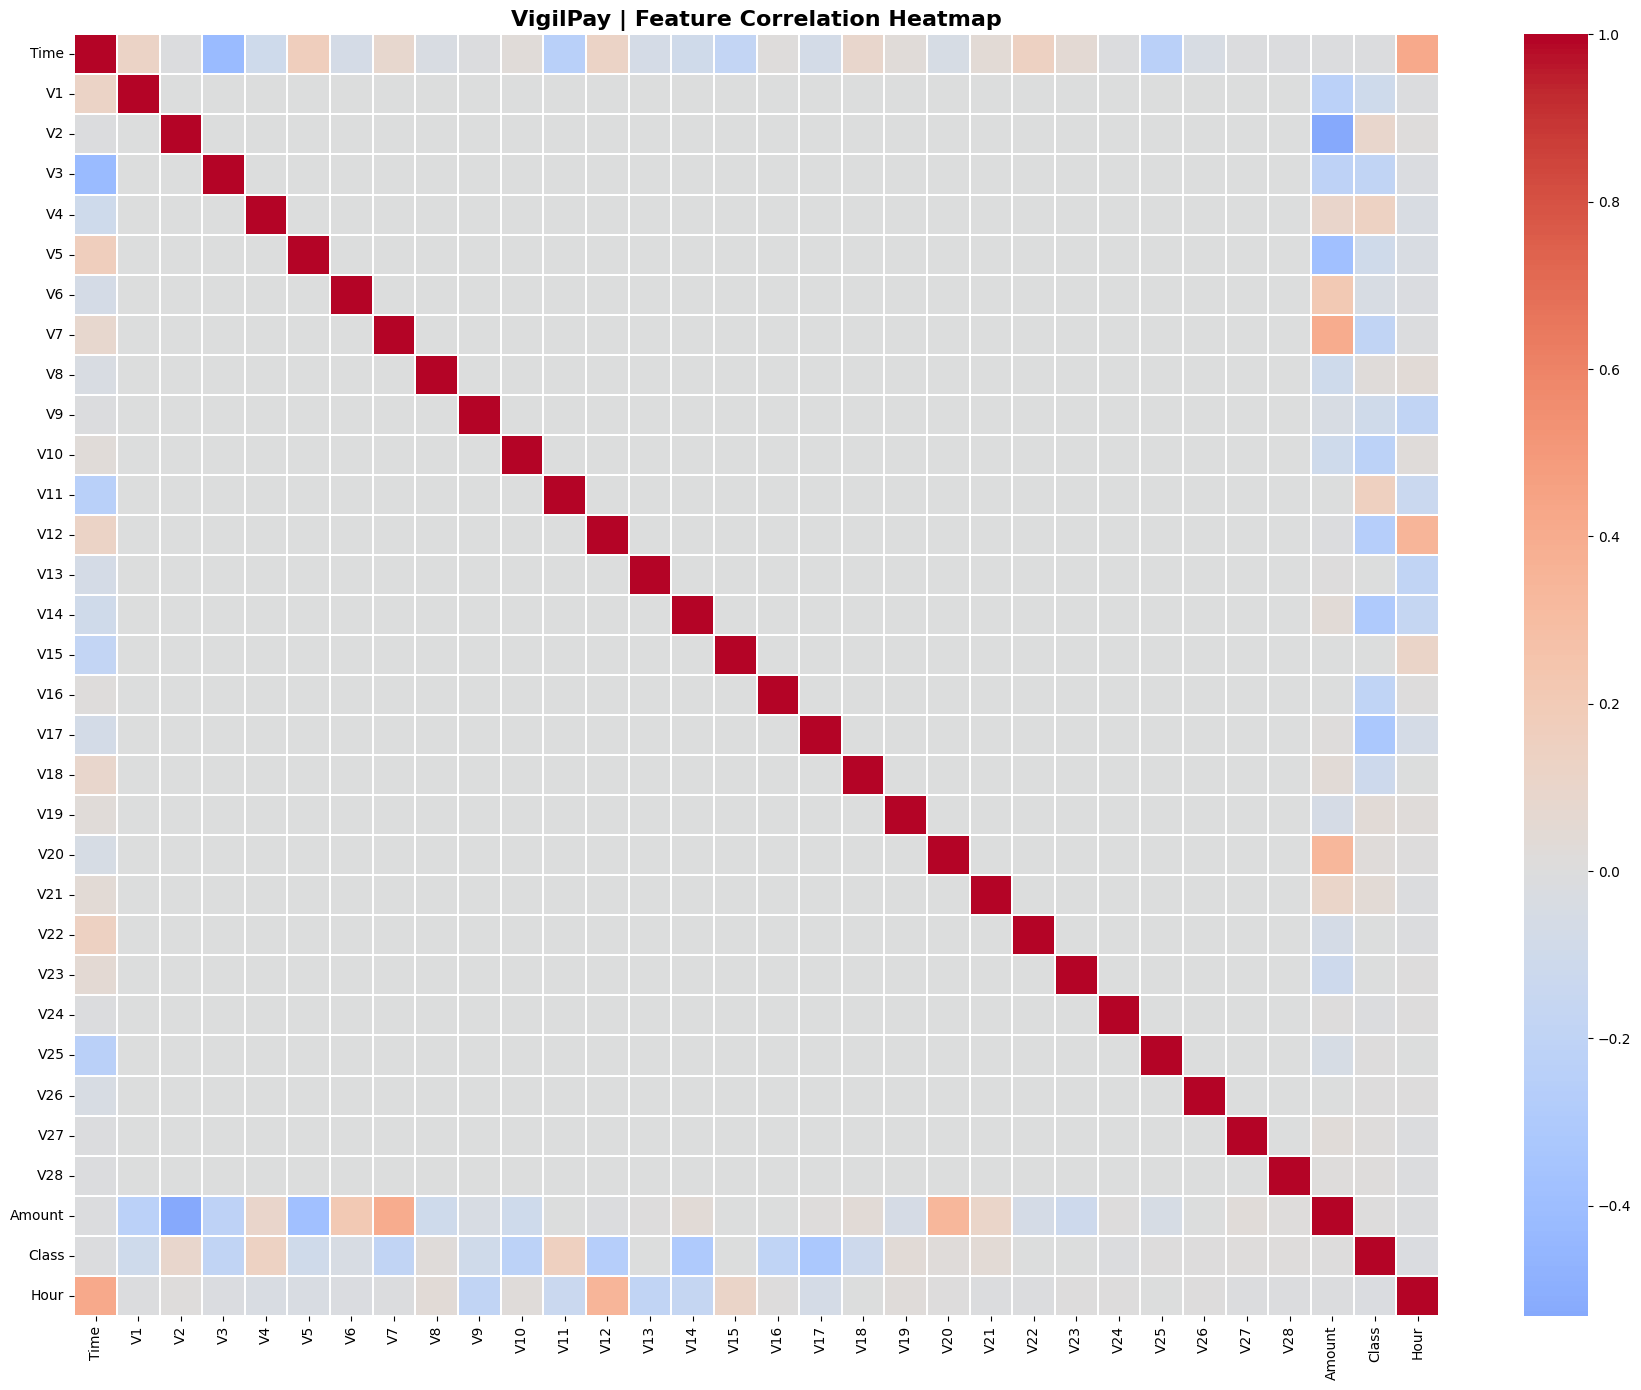

✅ Heatmap saved!


In [5]:
# Correlation heatmap — which features relate to fraud?
plt.figure(figsize=(18, 14))

corr = df.corr()

sns.heatmap(corr, 
            cmap='coolwarm',
            center=0,
            linewidths=0.1,
            annot=False)

plt.title('VigilPay | Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png')
plt.show()
print("✅ Heatmap saved!")

In [6]:
# Top features most correlated with Fraud
fraud_corr = df.corr()['Class'].drop('Class').sort_values()

print("🔴 Top features POSITIVELY correlated with Fraud:")
print(fraud_corr.tail(5))
print("\n🔵 Top features NEGATIVELY correlated with Fraud:")
print(fraud_corr.head(5))

🔴 Top features POSITIVELY correlated with Fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

🔵 Top features NEGATIVELY correlated with Fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [7]:
# VigilPay | Day 3 — EDA Summary & Key Findings

print("=" * 55)
print("   🛡️  VIGILPAY — EDA KEY FINDINGS SUMMARY")
print("=" * 55)

print("""
📊 DATASET:
   • 284,807 transactions | 31 features
   • Only 492 frauds (0.1727%) → severe class imbalance

💰 AMOUNT INSIGHTS:
   • Avg legitimate amount : £88.29
   • Avg fraud amount      : £122.21
   • Fraudsters avoid large amounts to stay hidden
   • Most fraud transactions are under £50

⏰ TIME INSIGHTS:
   • Legitimate txns peak during day (10AM - 10PM)
   • Fraud spikes at 2-3 AM (when users are asleep)
   • Second fraud peak around 11 AM

🔥 TOP FRAUD-DETECTING FEATURES:
   • V17 (corr: -0.33) → strongest negative signal
   • V14 (corr: -0.30) → second strongest
   • V11 (corr: +0.15) → strongest positive signal
   • V4  (corr: +0.13) → second positive signal

🎯 NEXT STEPS:
   • Day 4: Feature engineering & scaling
   • Day 5: Handle imbalance using SMOTE
   • Day 6: Train ML models (Logistic, XGBoost)
""")
print("=" * 55)
print("✅ EDA Complete! Ready for modelling.")

   🛡️  VIGILPAY — EDA KEY FINDINGS SUMMARY

📊 DATASET:
   • 284,807 transactions | 31 features
   • Only 492 frauds (0.1727%) → severe class imbalance

💰 AMOUNT INSIGHTS:
   • Avg legitimate amount : £88.29
   • Avg fraud amount      : £122.21
   • Fraudsters avoid large amounts to stay hidden
   • Most fraud transactions are under £50

⏰ TIME INSIGHTS:
   • Legitimate txns peak during day (10AM - 10PM)
   • Fraud spikes at 2-3 AM (when users are asleep)
   • Second fraud peak around 11 AM

🔥 TOP FRAUD-DETECTING FEATURES:
   • V17 (corr: -0.33) → strongest negative signal
   • V14 (corr: -0.30) → second strongest
   • V11 (corr: +0.15) → strongest positive signal
   • V4  (corr: +0.13) → second positive signal

🎯 NEXT STEPS:
   • Day 4: Feature engineering & scaling
   • Day 5: Handle imbalance using SMOTE
   • Day 6: Train ML models (Logistic, XGBoost)

✅ EDA Complete! Ready for modelling.
